<a href="https://colab.research.google.com/github/HussainAhmed75/NTI-AI-and-ML-exercises-/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df=pd.read_csv('/content/stroke.csv')

In [ ]:
df.info()
df['stroke'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   float64
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   float64
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   float64
 10  stroke             5110 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 439.3 KB


,count
stroke,
0,4861
1,249


In [ ]:
df.isnull().sum().sort_values(ascending=False)


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
X = df.drop(columns=['stroke'])
y = df['stroke']


In [ ]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0.5,0.816895,0,1,1,0.50,1,0.801265,0.301260,0.333333,1
1,0.0,0.743652,0,0,1,0.75,0,0.679023,0.212981,0.666667,1
2,0.5,0.975586,0,1,1,0.50,0,0.234512,0.254296,0.666667,1
3,0.0,0.597168,0,0,1,0.50,1,0.536008,0.276060,1.000000,1
4,0.0,0.963379,1,0,1,0.75,0,0.549349,0.156930,0.666667,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,0.0,0.975586,1,0,1,0.50,1,0.132167,0.212981,0.666667,0
5106,0.0,0.987793,0,0,1,0.75,1,0.323516,0.340206,0.666667,0
5107,0.0,0.426270,0,0,1,0.75,0,0.128658,0.232532,0.666667,0
5108,0.5,0.621582,0,0,1,0.50,0,0.513203,0.175258,0.333333,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
models ={
    "Logistic Regression":LogisticRegression()
}

Confusion Matrix:
[[972   0]
 [ 50   0]]


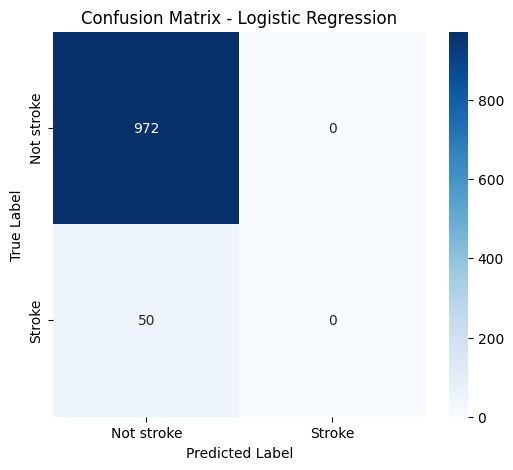


Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



,Model,Train Acc,Train Precision,Train Recall,Train F1,Test Acc,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.951321,0.0,0.0,0.0,0.951076,0.0,0.0,0.0


In [ ]:
accuracy = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    Acc_Train = accuracy_score(y_train, y_pred_train)
    Acc_Test  = accuracy_score(y_test, y_pred_test)

    Pre_Train = precision_score(y_train, y_pred_train, zero_division=0)
    Pre_Test  = precision_score(y_test, y_pred_test, zero_division=0)

    Rec_Train = recall_score(y_train, y_pred_train, zero_division=0)
    Rec_Test  = recall_score(y_test, y_pred_test, zero_division=0)

    F1_Train = f1_score(y_train, y_pred_train, zero_division=0)
    F1_Test  = f1_score(y_test, y_pred_test, zero_division=0)

    # Append results
    accuracy.append([
        model_name, Acc_Train, Pre_Train, Rec_Train, F1_Train,
        Acc_Test, Pre_Test, Rec_Test, F1_Test
    ])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    class_names = ['Not stroke', 'Stroke']

    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_test, zero_division=0))


# Convert results into dataframe
df_results = pd.DataFrame(accuracy, columns=[
    "Model","Train Acc","Train Precision","Train Recall","Train F1",
    "Test Acc","Test Precision","Test Recall","Test F1"
])

df_results


In [ ]:
errors =[]
for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred_train=model.predict(X_train)
  y_pred_test=model.predict(X_test)
  errors.append({
      "Model":name,
      "MSE_train":mean_squared_error(y_train,y_pred_train),
      "MSE_test":mean_squared_error(y_test,y_pred_test),
      "R2_train":r2_score(y_train,y_pred_train),
      "R2_test":r2_score(y_test,y_pred_test),
      "RMSE_train":np.sqrt(mean_squared_error(y_train,y_pred_train)),
      "RMSE_test":np.sqrt(mean_squared_error(y_test,y_pred_test)),

      })

In [ ]:
errors_df=pd.DataFrame(errors)
errors_df

,Model,MSE_train,MSE_test,R2_train,R2_test,RMSE_train,RMSE_test
0,Logistic Regression,0.048679,0.048924,-0.05117,-0.05144,0.220633,0.221187
